# Installing Libraries and Pre Requisites


In [ ]:
!pip install --upgrade transformers datasets accelerate evaluate
!pip install nltk textblob vaderSentiment
!pip install wordcloud

import pandas as pd
import numpy as np

import re
import string

import matplotlib.pyplot as plt
import seaborn as sns

from wordcloud import WordCloud

from textblob import TextBlob
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

from sklearn.model_selection import train_test_split

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    f1_score
)

from sklearn.linear_model import LogisticRegression

from scipy.sparse import hstack

import warnings
warnings.filterwarnings("ignore")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 46.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 21.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 389.2/389.2 kB 16.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 11.2 MB/s eta 0:00:00
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 18.1.0
    Uninstalling pyarrow-18.1.0:
      Successfully uninstalled pyarrow-18.1.0
  Attempting uninstall: datasets
    Found existing installation: datasets 4.0.0
    Uninstalling datasets-4.0.0:
      Successfully uninstalled datasets-4.0.0
  Attempting uninstall: accelerate
    Found existing installation: accelerate 1.13.0
    Uninstalling accelerate-1.13.0:
      Successfully uninstalled accelerate-1.13.0
  Attempting uninstall: transformers
    Found existing installation: transformers 5.10.1
    Uninstalling trans

In [ ]:
import transformers
import datasets

# Load Dataset


In [ ]:
df = pd.read_csv(
"/content/drive/MyDrive/FAKE REVIEW PROJECT ML 2026 JUNE/Dataset/fake reviews dataset.csv"
)

df.head()

,category,rating,label,text_
0,Home_and_Kitchen_5,5.0,CG,"Love this! Well made, sturdy, and very comfor..."
1,Home_and_Kitchen_5,5.0,CG,"love it, a great upgrade from the original. I..."
2,Home_and_Kitchen_5,5.0,CG,This pillow saved my back. I love the look and...
3,Home_and_Kitchen_5,1.0,CG,"Missing information on how to use it, but it i..."
4,Home_and_Kitchen_5,5.0,CG,Very nice set. Good quality. We have had the s...


# Feature Engineering and Preprocessing


In [ ]:
print(df.shape)

(40432, 4)


In [ ]:
print(df.isnull().sum())

category    0
rating      0
label       0
text_       0
dtype: int64


In [ ]:
print(df['label'].value_counts())

label
CG    20216
OR    20216
Name: count, dtype: int64


In [ ]:
print(df.dtypes)

category     object
rating      float64
label        object
text_        object
dtype: object


In [ ]:
print(df.isnull().sum())

category    0
rating      0
label       0
text_       0
dtype: int64


In [ ]:
df['label'] = df['label'].map({
    'CG':1,
    'OR':0
})

In [ ]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"www\S+", "", text)
    text = re.sub(r"<.*?>", "", text)
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    text = re.sub(r"\s+", " ", text)

    return text.strip()

df['clean_text'] = df['text_'].apply(clean_text)

In [ ]:
analyzer = SentimentIntensityAnalyzer()

df['review_length'] = df['text_'].apply(len)

df['word_count'] = df['text_'].apply(
    lambda x: len(str(x).split())
)

df['exclamation_count'] = df['text_'].apply(
    lambda x: str(x).count("!")
)

df['capital_ratio'] = df['text_'].apply(
    lambda x:
    sum(c.isupper() for c in str(x)) / (len(str(x))+1)
)

df['sentiment_score'] = df['text_'].apply(
    lambda x:
    analyzer.polarity_scores(str(x))['compound']
)

In [ ]:
category_encoder = LabelEncoder()

df['category_encoded'] = category_encoder.fit_transform(
    df['category']
)

In [ ]:
df.head()

,category,rating,label,text_,clean_text,review_length,word_count,exclamation_count,capital_ratio,sentiment_score,category_encoded
0,Home_and_Kitchen_5,5.0,1,"Love this! Well made, sturdy, and very comfor...",love this well made sturdy and very comfortabl...,75,12,2,0.052632,0.9592,3
1,Home_and_Kitchen_5,5.0,1,"love it, a great upgrade from the original. I...",love it a great upgrade from the original i ve...,80,16,0,0.012346,0.8910,3
2,Home_and_Kitchen_5,5.0,1,This pillow saved my back. I love the look and...,this pillow saved my back i love the look and ...,67,14,0,0.029412,0.7906,3
3,Home_and_Kitchen_5,1.0,1,"Missing information on how to use it, but it i...",missing information on how to use it but it is...,81,17,1,0.024390,0.7463,3
4,Home_and_Kitchen_5,5.0,1,Very nice set. Good quality. We have had the s...,very nice set good quality we have had the set...,85,18,0,0.034884,0.7397,3


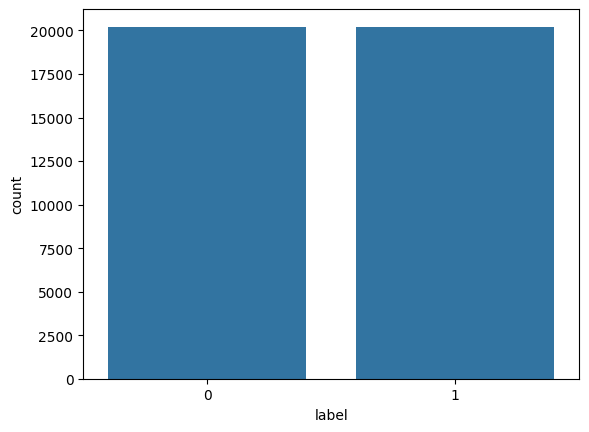

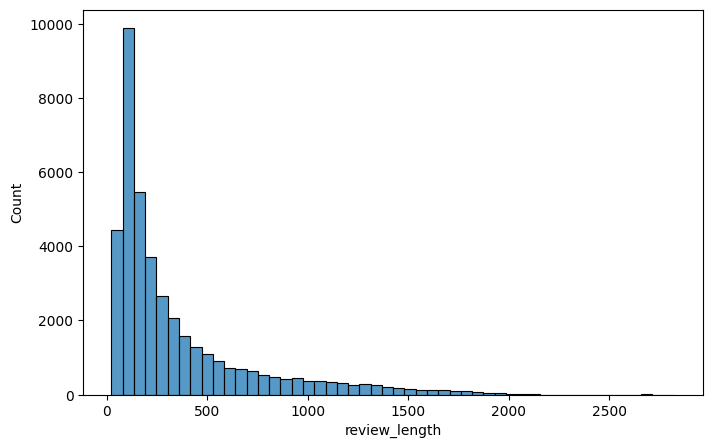

In [ ]:
sns.countplot(
    x='label',
    data=df
)

plt.show()


plt.figure(figsize=(8,5))

sns.histplot(
    df['review_length'],
    bins=50
)

plt.show()

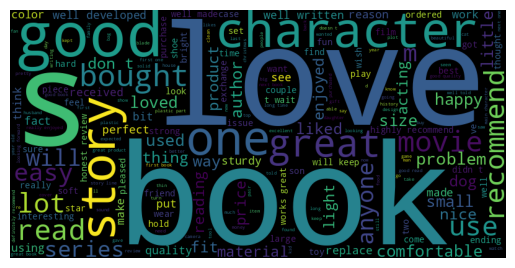

In [ ]:
fake_reviews = " ".join(
    df[df.label==1]['clean_text']
)
wc = WordCloud(
    width=800,
    height=400
).generate(fake_reviews)

plt.imshow(wc)

plt.axis("off")

plt.show()

# TRAIN-TEST SPLIT


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    df,
    df['label'],
    test_size=0.2,
    random_state=21,
    stratify=df['label']
)

# TF-IDF & Logistic Regression Model


In [ ]:
tfidf = TfidfVectorizer(

    max_features=15000,
    ngram_range=(1,2),
    stop_words='english'
)

X_train_text = tfidf.fit_transform(
    X_train['clean_text']
)

X_test_text = tfidf.transform(
    X_test['clean_text']
)

**Training Model**

In [30]:
lr_model = LogisticRegression(
    max_iter=3000
)

lr_model.fit(
    X_train_text,
    y_train
)

LogisticRegression(max_iter=3000)

**Evaluating the LR Model**

In [31]:
pred_lr = lr_model.predict(
    X_test_text
)
print(
    classification_report(
        y_test,pred_lr
    )
)
print(
    "Accuracy:",
    accuracy_score(
        y_test,pred_lr
    )
)
print(
    "F1:",
    f1_score(
        y_test,pred_lr
    )
)

              precision    recall  f1-score   support

           0       0.88      0.89      0.89      4043
           1       0.89      0.87      0.88      4044

    accuracy                           0.88      8087
   macro avg       0.88      0.88      0.88      8087
weighted avg       0.88      0.88      0.88      8087

Accuracy: 0.8845059972795846
F1: 0.883337496877342


# Saving the Model

In [32]:
import joblib

joblib.dump(
    lr_model,
    "logistic_regression_model.pkl"
)

['logistic_regression_model.pkl']

In [33]:
joblib.dump(
    tfidf,
    "tfidf_vectorizer.pkl"
)

['tfidf_vectorizer.pkl']

In [34]:
joblib.dump(
    category_encoder,
    "category_encoder.pkl"
)

['category_encoder.pkl']

In [35]:
import os

print(os.listdir())

['.config', 'category_encoder.pkl', 'tfidf_vectorizer.pkl', 'logistic_regression_model.pkl', 'drive', 'sample_data']


In [36]:
from google.colab import files

files.download("logistic_regression_model.pkl")
files.download("tfidf_vectorizer.pkl")
files.download("category_encoder.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [37]:
import joblib

model = joblib.load(
    "logistic_regression_model.pkl"
)

print(model.n_features_in_)

15000
